## LIBRARY IMPORTS

In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import joblib

/opt/anaconda3/envs/188/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LOADING DATA / EXPLORING + SEPARATING NEEDED PARTS

In [2]:
# Download latest version
path = kagglehub.dataset_download("mansibmursalin/ninapro-db1-full-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1


In [3]:
#/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1
print(path)
print(os.path.exists(path))
print(os.listdir(path))

/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1
True
['Ninapro_DB1.csv']


In [4]:
for root, dirs, files in os.walk(path):
    print(root)
    for f in files:
        print("   ", f)

/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1
    Ninapro_DB1.csv


In [5]:
dataset = pd.read_csv(
    "/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1/Ninapro_DB1.csv"
)
print(dataset.head)

<bound method NDFrame.head of           Unnamed: 0   emg_0   emg_1   emg_2   emg_3   emg_4   emg_5   emg_6  \
0                  0  0.0024  0.0024  0.0024  0.0024  0.0024  0.0098  0.0146   
1                  1  0.0024  0.0024  0.0024  0.0024  0.0024  0.0098  0.0122   
2                  2  0.0024  0.0024  0.0024  0.0024  0.0024  0.0073  0.0073   
3                  3  0.0049  0.0024  0.0024  0.0024  0.0024  0.0073  0.0049   
4                  4  0.0049  0.0024  0.0024  0.0024  0.0024  0.0024  0.0024   
...              ...     ...     ...     ...     ...     ...     ...     ...   
12553606      217538  0.0024  0.0024  0.0024  0.0024  0.0024  0.0342  0.0854   
12553607      217539  0.0024  0.0024  0.0024  0.0024  0.0024  0.0464  0.0757   
12553608      217540  0.0024  0.0024  0.0024  0.0024  0.0024  0.0537  0.0635   
12553609      217541  0.0024  0.0024  0.0024  0.0024  0.0024  0.0586  0.0562   
12553610      217542  0.0024  0.0024  0.0024  0.0024  0.0024  0.0635  0.0464   

         

In [6]:
print(dataset.columns)

Index(['Unnamed: 0', 'emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5',
       'emg_6', 'emg_7', 'emg_8', 'emg_9', 'glove_0', 'glove_1', 'glove_2',
       'glove_3', 'glove_4', 'glove_5', 'glove_6', 'glove_7', 'glove_8',
       'glove_9', 'glove_10', 'glove_11', 'glove_12', 'glove_13', 'glove_14',
       'glove_15', 'glove_16', 'glove_17', 'glove_18', 'glove_19', 'glove_20',
       'glove_21', 'exercise', 'stimulus', 'restimulus', 'repetition',
       'rerepetition', 'subject'],
      dtype='object')


emg_0 through emg_9 would be the features (X) and either stimulus or restimulus would be the output (Y)

In [7]:
print(dataset.iloc[5: 7])

   Unnamed: 0   emg_0   emg_1   emg_2   emg_3   emg_4   emg_5   emg_6   emg_7  \
5           5  0.0024  0.0024  0.0024  0.0024  0.0024  0.0024  0.0024  0.0293   
6           6  0.0024  0.0024  0.0024  0.0024  0.0024  0.0024  0.0024  0.0293   

    emg_8  ...  glove_18  glove_19  glove_20  glove_21  exercise  stimulus  \
5  0.0024  ...     141.0     150.0     147.0     113.0         1         0   
6  0.0024  ...     141.0     150.0     147.0     113.0         1         0   

   restimulus  repetition  rerepetition  subject  
5           0           0             0       10  
6           0           0             0       10  

[2 rows x 39 columns]


In [8]:
restim_counts = dataset["restimulus"].value_counts()
restim_counts

restimulus
0     7290845
3      307321
1      303720
8      303280
11     299941
2      299072
7      298404
12     298227
9      297929
6      292612
4      290830
10     290622
5      287942
17     218351
16     209762
15     200609
13     197325
14     194345
23     124115
20     115854
19     110345
18     108121
21     107846
22     106193
Name: count, dtype: int64

In [9]:
exercise_counts = dataset["exercise"].value_counts()
exercise_counts

exercise
3    5953650
2    3868568
1    2731393
Name: count, dtype: int64

In [10]:
exercise2_df = dataset[dataset["exercise"] == 2]
exercise2_df.iloc[:3]

,Unnamed: 0,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,...,glove_18,glove_19,glove_20,glove_21,exercise,stimulus,restimulus,repetition,rerepetition,subject
100778,0,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0415,0.0708,0.0024,...,141.0,179.0,148.0,111.0,2,0,0,0,0,10
100779,1,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0366,0.0659,0.0024,...,141.0,179.0,148.0,111.0,2,0,0,0,0,10
100780,2,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0293,0.0684,0.0024,...,141.0,179.0,148.0,111.0,2,0,0,0,0,10


In [11]:
exercise2_df.shape

(3868568, 39)

In [12]:
exercise2_counts = exercise2_df["restimulus"].value_counts()
exercise2_counts

restimulus
0     2228723
16     105868
1      104807
17     102953
11     102617
9      102373
2       98023
13      97912
12      96970
4       96902
7       96855
10      96809
8       95915
3       95261
5       87657
15      87300
6       86181
14      85442
Name: count, dtype: int64

In [13]:
new_dataset = exercise2_df[exercise2_df["restimulus"].isin([1, 2, 3, 6, 7])]
new_dataset.shape

(481127, 39)

In [14]:
emg_labels = new_dataset["restimulus"]
print(emg_labels)
print(emg_labels.shape)

101140      1
101141      1
101142      1
101143      1
101144      1
           ..
12251798    7
12251799    7
12251800    7
12251801    7
12251802    7
Name: restimulus, Length: 481127, dtype: int64
(481127,)


## VISUALIZING DATA

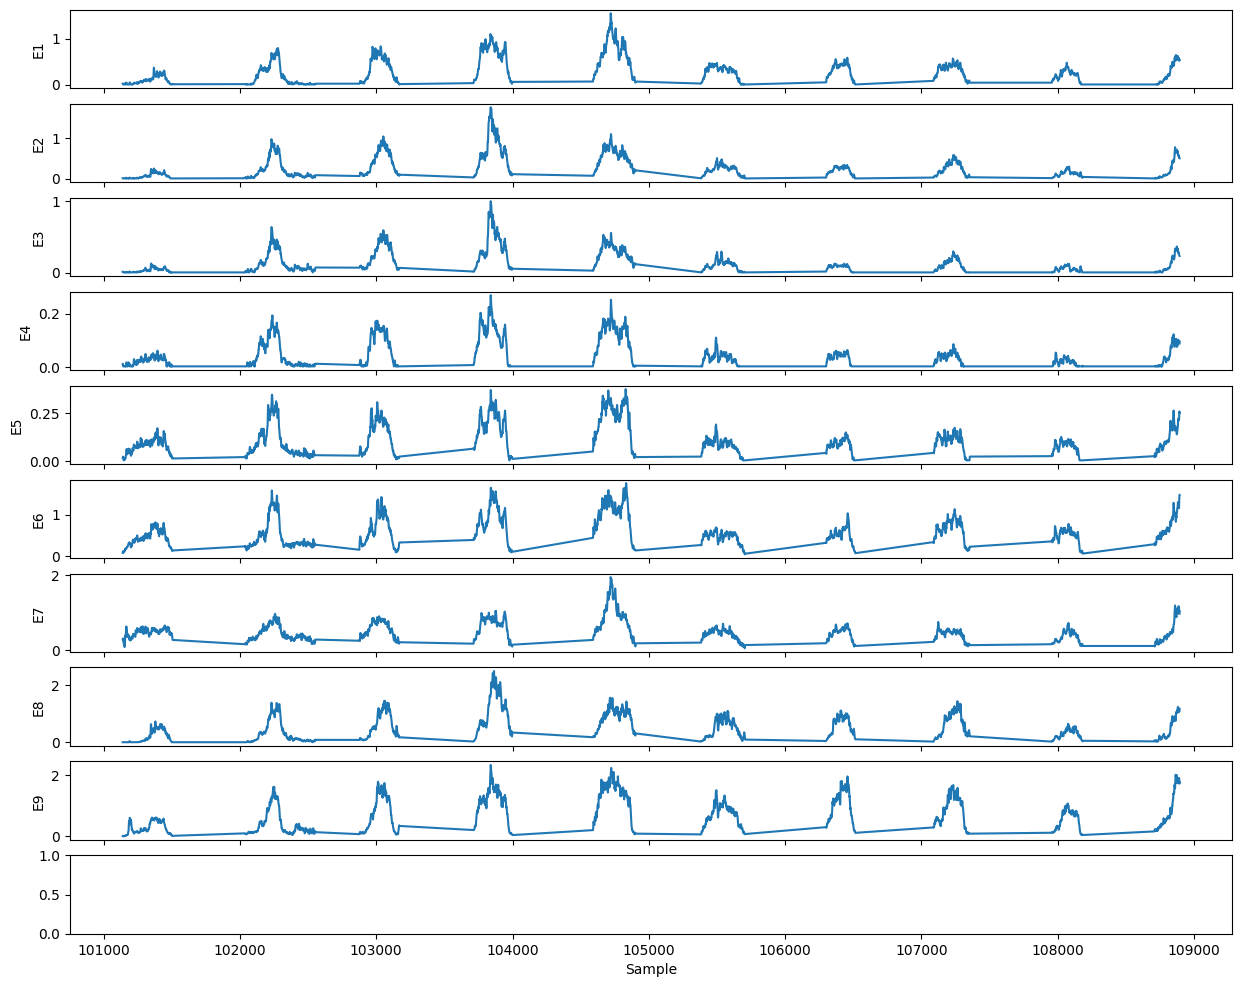

In [15]:
fig, axes = plt.subplots(10, 1, figsize=(15,12), sharex=True)

for i in range(9):
    axes[i].plot(new_dataset[f"emg_{i+1}"][:3000])
    axes[i].set_ylabel(f"E{i+1}")

plt.xlabel("Sample")
plt.show()

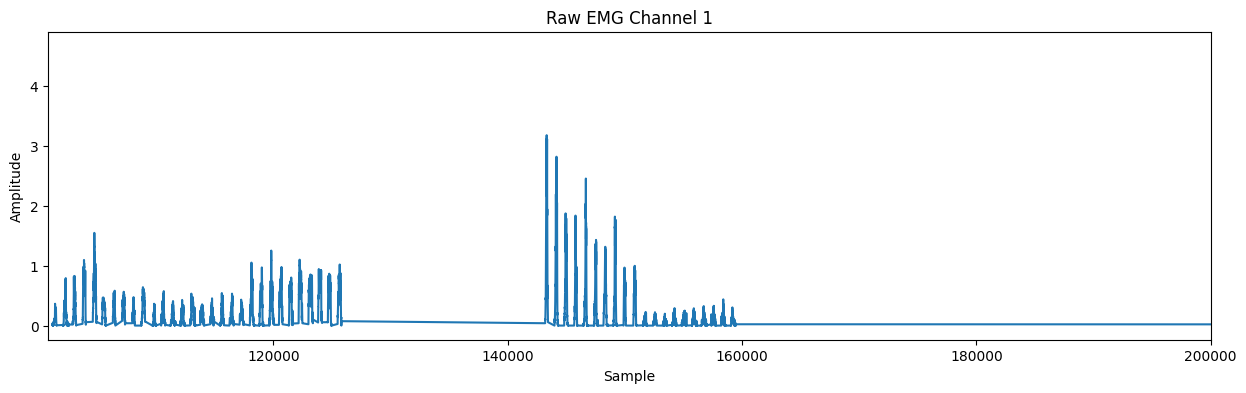

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(new_dataset["emg_1"])

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Raw EMG Channel 1")
plt.xlim(100778, 200000)
plt.show()

## __FILTERING NOISE OUT__

In [17]:
emgs = ["emg_0", "emg_1", "emg_2", "emg_3", "emg_4", "emg_5", "emg_6", "emg_7", "emg_8", "emg_9"]
emg_channels = new_dataset[emgs]
emg_channels.columns

Index(['emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5', 'emg_6', 'emg_7',
       'emg_8', 'emg_9'],
      dtype='object')

In [18]:
emg_channels.head

<bound method NDFrame.head of            emg_0   emg_1   emg_2   emg_3   emg_4   emg_5   emg_6   emg_7  \
101140    0.0293  0.0220  0.0098  0.0122  0.0098  0.0146  0.0732  0.2856   
101141    0.0269  0.0244  0.0098  0.0146  0.0122  0.0195  0.0928  0.3101   
101142    0.0220  0.0195  0.0049  0.0122  0.0098  0.0220  0.1074  0.3149   
101143    0.0195  0.0122  0.0024  0.0049  0.0024  0.0195  0.1123  0.2954   
101144    0.0195  0.0024  0.0024  0.0024  0.0024  0.0146  0.1172  0.2637   
...          ...     ...     ...     ...     ...     ...     ...     ...   
12251798  0.0171  0.0024  0.0024  0.0024  0.0024  0.0024  0.1294  0.0024   
12251799  0.0171  0.0024  0.0024  0.0024  0.0024  0.0024  0.1294  0.0049   
12251800  0.0171  0.0024  0.0024  0.0024  0.0024  0.0024  0.1294  0.0073   
12251801  0.0171  0.0024  0.0024  0.0024  0.0024  0.0024  0.1318  0.0098   
12251802  0.0171  0.0024  0.0024  0.0024  0.0024  0.0024  0.1270  0.0122   

           emg_8   emg_9  
101140    0.0024  0.0049  
101

In [19]:
from scipy.signal import butter, filtfilt, sosfiltfilt

def signal_filtering(dataset_signals):

    frequency_rate = 100
    low_hz = 20
    high_hz = 45

    sos = butter(N=4, Wn=[low_hz, high_hz], btype="band", fs=frequency_rate, output="sos")

    filtered_signals = sosfiltfilt(sos, dataset_signals, axis=0)

    return filtered_signals


In [20]:
emg_filtered = signal_filtering(emg_channels)

In [21]:
print(f"First: {emg_filtered[1]}")

First: [ 1.57014600e-03  1.57535069e-03  1.91864874e-03  1.61167346e-03
  1.97067142e-03  6.40904293e-06  1.20277124e-03  1.37274116e-03
 -2.68200147e-06 -3.81336894e-03]


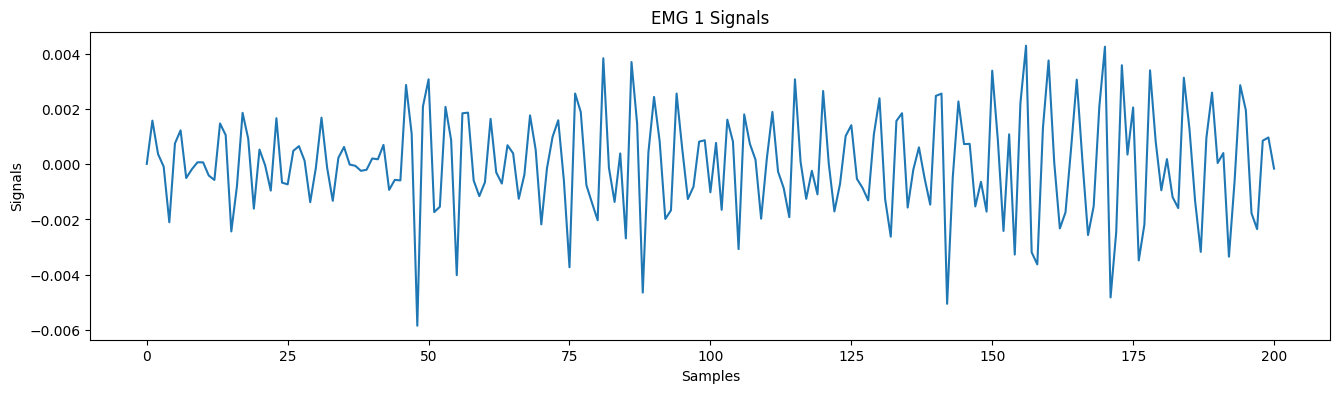

In [22]:
plt.figure(figsize=(16,4))
plt.plot(emg_filtered[: 201, 1])
plt.xlabel("Samples")
plt.ylabel("Signals")
plt.title("EMG 1 Signals")
plt.show()

## __BATCHING__

In [42]:
WINDOW = 250

def create_windows(signal):

    windows = []

    for i in range(0, len(signal) - WINDOW, WINDOW):

        windows.append(signal[i : i + WINDOW])

    return np.array(windows)

In [43]:
batches = create_windows(emg_filtered)
print(batches.shape)
#(2405, 200, 10) > 2405 batches, 200 rows per batch, 10 cols per batch

(1924, 250, 10)


In [44]:
#joblib.dump(batches, "my_models/feature_batches.pkl")

In [45]:
label_batches = create_windows(emg_labels)
print(label_batches)
print(label_batches.shape)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [7 7 7 ... 7 7 7]
 [7 7 7 ... 7 7 7]
 [7 7 7 ... 7 7 7]]
(1924, 250)


In [46]:
#joblib.dump(label_batches, "my_models/label_batches.pkl")

## __SERIALIZATION X_TEST & Y_TEST__
Going back to do this for deployment

In [56]:
from scipy.stats import mode

window_labels = mode(label_batches, axis=1).mode.flatten()

print(window_labels.shape)

(1924,)


In [57]:
labels, counts = np.unique(window_labels, return_counts=True)

print(np.column_stack((labels, counts)))

[[  1 419]
 [  2 392]
 [  3 383]
 [  6 346]
 [  7 384]]


In [58]:
from sklearn.model_selection import train_test_split

X_train_windows, X_test_windows, y_train, y_test = train_test_split(
    batches,
    window_labels,
    test_size=0.2,
    random_state=42,
    stratify=window_labels
)

In [59]:
print(X_train_windows.shape)
print(X_test_windows.shape)
print(y_train.shape)
print(y_test.shape)

(1539, 250, 10)
(385, 250, 10)
(1539,)
(385,)


In [63]:
joblib.dump(X_test_windows, "ml/raw_feature_windows.pkl")

['ml/raw_feature_windows.pkl']

In [64]:
joblib.dump(y_test, "ml/raw_label_windows.pkl")

['ml/raw_label_windows.pkl']

## __END OF SERIALIZATION__

## __FEATURES__

In [65]:
"""
1. MAV: How hard the muscle is contracting. A higher MAV the stronger the muscle contracts.

2. RMS: RMS is another signal strength measurement. Muscle power, the higher the value the larger the spikes will be... stronger contractions.


3. Wave Length, WL: How much the signal changes over time
Suppose you have the following:
1   |2-1| = 1       1   4
2   |3-2| = 1       5   3
3   |4-3| = 1       2   6
4   WL = 3          8   WL = 13
The second signal is more "active". It helps distinguish gestures that may have similar strenght but diff patterns.


4. Zero Crossing, ZC: How often the signal oscillates. It counts how many times the signal crossed 0. The more crossings the more there is muscle activity bec of the higher frequency.
+ - + - + - +           +++++++
↓                       v
6 crossings             0 crossings


5. Slope Sign Changes, SSC: How frequently the signal changes direction
      /\
     /  \
____/    \ ____
goes up and down once

/\ /\ /\ /\
this is what a noisy signal might look like

6. Willison Amplitude, WAMP: How many significant changes occur, it counts large changes between neighboring samples.
Suppose the threshold is 0.2
0.1
v       0.05
0.15
v       0.03
0.18
v       0.03
0.21
v       0.59
0.8
Only the last diff is larger than 0.2 so WAMP = 1

7. Variance: How spread out the signal values are
8. Integrated EMG, IEMG: Total muscle activity over the window
"""

'\n1. MAV: How hard the muscle is contracting. A higher MAV the stronger the muscle contracts.\n\n2. RMS: RMS is another signal strength measurement. Muscle power, the higher the value the larger the spikes will be... stronger contractions.\n\n\n3. Wave Length, WL: How much the signal changes over time\nSuppose you have the following:\n1   |2-1| = 1       1   4\n2   |3-2| = 1       5   3\n3   |4-3| = 1       2   6\n4   WL = 3          8   WL = 13\nThe second signal is more "active". It helps distinguish gestures that may have similar strenght but diff patterns.\n\n\n4. Zero Crossing, ZC: How often the signal oscillates. It counts how many times the signal crossed 0. The more crossings the more there is muscle activity bec of the higher frequency.\n+ - + - + - +           +++++++\n↓                       v\n6 crossings             0 crossings\n\n\n5. Slope Sign Changes, SSC: How frequently the signal changes direction\n      /     /  ____/    \\ ____\ngoes up and down once\n\n/\\ /\\ /\

__MEAN ABSOLUTE VALUES (MAV)__

In [68]:
def mav(emg_baches):
    mav_baches = np.mean(np.abs(emg_baches), axis=1)
    return mav_baches

In [70]:
mav_features = mav(batches)
print(mav_features[1])
print(mav_features.shape)

[0.00071021 0.00230027 0.0017136  0.00130663 0.00081962 0.0014661
 0.00481839 0.00560557 0.00320896 0.00355748]
(1924, 10)


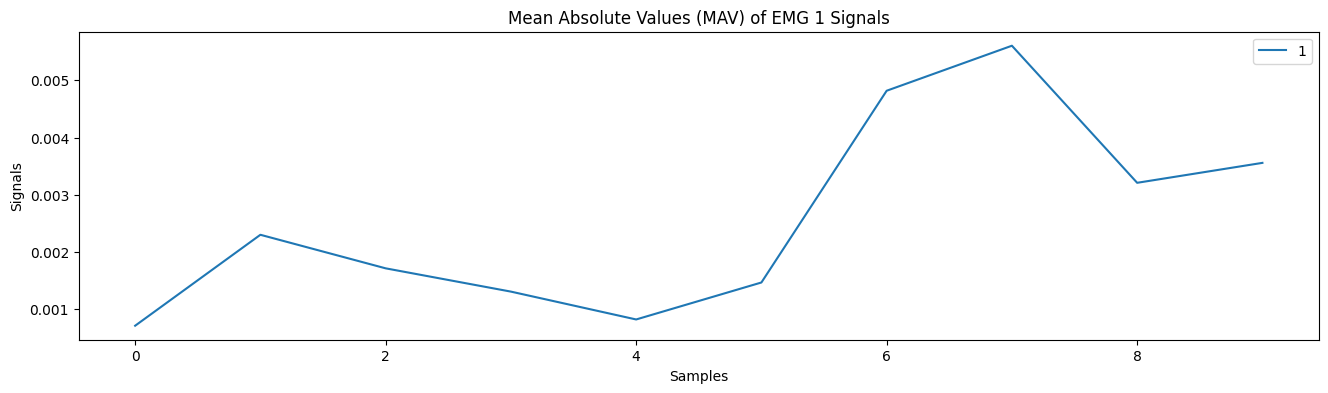

In [95]:
plt.figure(figsize=(16,4))
plt.plot(mav_features[1][: 201])
plt.xlabel("Samples")
plt.ylabel("Signals")
plt.title("Mean Absolute Values (MAV) of EMG 1 Signals")
plt.legend("1")
plt.show()

__ROOT MEAN SQUARE (RMS)__

In [69]:
def rms(emg_batches):
        rms_values = np.sqrt(np.mean(emg_batches**2, axis=1))
        return rms_values

In [97]:
rms_features = rms(batches)
print(rms_features[1])
print(rms_features.shape)

[0.00089005 0.00321544 0.0023351  0.0017652  0.0011315  0.00182265
 0.00678321 0.00719217 0.00463787 0.00495323]
(1924, 10)


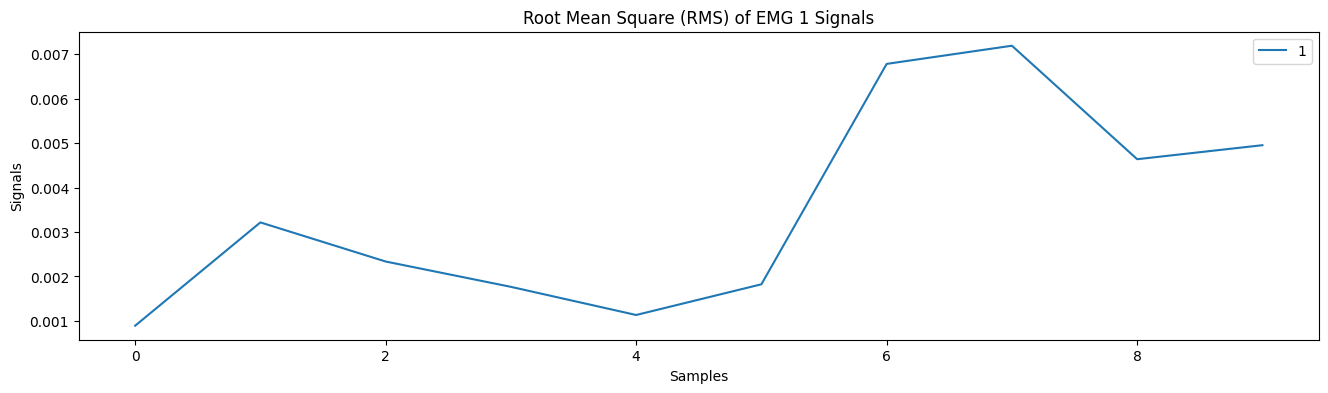

In [98]:
plt.figure(figsize=(16,4))
plt.plot(rms_features[1][: 201])
plt.xlabel("Samples")
plt.ylabel("Signals")
plt.title("Root Mean Square (RMS) of EMG 1 Signals")
plt.legend("1")
plt.show()

__WAVE LENGTH__

In [99]:
def wl(emg_batches):
    wave_length = np.sum(np.abs(np.diff(emg_batches, axis=1)), axis=1)
    return wave_length

In [100]:
wl_features = wl(batches)
print(wl_features)
print(wl_features.shape)

[[2.64164972e-01 7.03530068e-01 5.51134278e-01 ... 2.05284063e+00
  7.65674046e-01 1.39062347e+00]
 [2.87597273e-01 8.55895456e-01 6.36289911e-01 ... 2.07914146e+00
  1.17276178e+00 1.35561933e+00]
 [2.36796273e-01 1.41197092e+00 1.51190697e+00 ... 1.95926353e+00
  2.03971330e+00 2.45011273e+00]
 ...
 [3.06748155e-01 1.79934961e-02 9.99237680e-02 ... 2.30490037e-01
  3.72038780e-04 2.66763583e-02]
 [2.88614771e-01 8.01602241e-01 6.44241031e-01 ... 2.22976866e-01
  2.39654586e+00 8.41109540e-01]
 [3.19067541e-01 1.13830298e+00 8.30178873e-01 ... 3.02578181e-01
  1.87091630e+00 8.66192449e-01]]
(1924, 10)


__ZERO CROSSINGS__

In [101]:
def zc(emg_batches, threshold=0):
    diff = emg_batches[:, :-1, :] * emg_batches[:, 1:, :]
    zero_crossings = np.sum(diff < threshold, axis=1)
    return zero_crossings

In [102]:
zc_features = zc(batches)

print(zc_features.shape)
print(zc_features[0])

(1924, 10)
[145 125 143 132 147 126 140 143 158 125]


In [103]:
def ssc(emg_batches, threshold=0):
    diff1 = emg_batches[:, 1:-1, :] - emg_batches[:, :-2, :]

    diff2 = emg_batches[:, 1:-1, :] - emg_batches[:, 2:, :]

    ssc = diff1 * diff2

    slope_sign_changes = np.sum(ssc > threshold, axis=1)

    return slope_sign_changes

In [104]:
ssc_features = ssc(batches)

print(ssc_features.shape)
print(ssc_features[0])

(1924, 10)
[153 139 153 144 166 138 149 151 174 139]


__VARIANCE__

In [105]:
def variance(emg_batches):
    var = np.var(emg_batches, ddof=1, axis=1)

    return var

In [106]:
variance_features = variance(batches)
print(variance_features.shape)

(1924, 10)


## __ML__

In [107]:
features = np.hstack([mav_features, rms_features, wl_features, zc_features, ssc_features, variance_features])
features.shape

(1924, 60)

In [108]:
print(features[1])
print(features[1].shape)

[7.10212238e-04 2.30026752e-03 1.71360472e-03 1.30662586e-03
 8.19620052e-04 1.46609695e-03 4.81839464e-03 5.60557197e-03
 3.20895636e-03 3.55747545e-03 8.90054175e-04 3.21543760e-03
 2.33510192e-03 1.76520265e-03 1.13150248e-03 1.82264528e-03
 6.78321418e-03 7.19216935e-03 4.63786861e-03 4.95323459e-03
 2.87597273e-01 8.55895456e-01 6.36289911e-01 5.13425540e-01
 3.17020428e-01 5.44873925e-01 1.87705231e+00 2.07914146e+00
 1.17276178e+00 1.35561933e+00 1.44000000e+02 1.32000000e+02
 1.24000000e+02 1.32000000e+02 1.36000000e+02 1.40000000e+02
 1.33000000e+02 1.34000000e+02 1.38000000e+02 1.42000000e+02
 1.50000000e+02 1.51000000e+02 1.27000000e+02 1.43000000e+02
 1.47000000e+02 1.45000000e+02 1.44000000e+02 1.46000000e+02
 1.44000000e+02 1.47000000e+02 7.95346068e-07 1.03796243e-05
 5.47449092e-06 3.12845367e-06 1.28543126e-06 3.33522416e-06
 4.61965459e-05 5.19328248e-05 2.15959585e-05 2.46323858e-05]
(60,)


In [109]:
X = features
Y = label_batches

In [110]:
print(X.shape)
print(Y.shape)
print(Y[150])
print(Y[15])

(1924, 60)
(1924, 250)
[7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 

In [111]:
import numpy as np

for i in range(1603):
    print(np.unique(label_batches[i]))

[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1 2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2 3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3 6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6 7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[1 7]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1 2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2 3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3 6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6 7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[1 7]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1 2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2 3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3 6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6 7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[1 7]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1 2]
[2]
[2]
[2]


In [112]:
mixed = 0

for window in label_batches:
    if len(np.unique(window)) > 1:
        mixed += 1

print(mixed)

134


In [113]:
from scipy.stats import mode

window_labels = mode(label_batches, axis=1).mode.flatten()

In [114]:
window_labels.shape

(1924,)

In [115]:
for i in range(1603):
    print(np.unique(window_labels[i]))

[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[6]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]
[2]


## __SVM / SVC__

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_features = features
y_labels = window_labels

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

In [146]:
#X_train_val, X_test, y_train_val, y_test = train_test_split(X_features, y_labels, test_size=0.1, random_state=42, stratify=y_labels)

#X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.22222, random_state=42, stratify=y_train_val)

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#X_val = scaler.transform(X_val)

In [148]:
print(X_train[1])

[-0.55138395 -0.8281813   0.59112961  0.90902169  0.05290061 -0.36187061
  0.01880868  0.85824505  1.22551286  1.18348488 -0.57535317 -0.79708145
  0.59028075  0.94323572 -0.00828725 -0.3732992  -0.05900633  0.62813402
  1.18571335  1.18518492 -0.53904388 -0.85305883  0.56196183  0.93643318
  0.08013902 -0.38776967 -0.02405687  0.77023977  1.19646841  1.01598304
  0.30392006  0.38085008 -0.42024787 -0.1706157  -0.66241412 -0.31689355
 -0.33461086  1.06604554 -0.70976535 -0.1151277  -0.23938084  0.36213727
 -0.03075571 -0.06600956 -0.50929383 -0.49672336 -1.058613   -0.25106024
 -0.89609238 -0.35260674 -0.54229247 -0.50622321  0.12096984  0.36791526
 -0.10196954 -0.25028711 -0.27797222  0.26561475  0.7216857   0.79176971]


In [135]:
params = {
    "kernel": ["rbf"],
    "C": [10, 15, 20, 25, 50, 75, 100],
    "gamma": [0.1, 0.5, 1, 5, 20, 50, 100, 200],
}

In [136]:
from sklearn.model_selection import GridSearchCV

svc = GridSearchCV(estimator=SVC(), param_grid=params, cv=10, scoring="accuracy")
#svc = SVC(**params)

In [137]:
svc.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [10, 15, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [138]:
pred = svc.predict(X_val)

In [139]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7220779220779221


In [250]:
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(y_test, pred, output_dict=True)

print(report)

#print(confusion_matrix(y_test, pred))

{'1': {'precision': 0.7093023255813954, 'recall': 0.7261904761904762, 'f1-score': 0.7176470588235294, 'support': 84.0}, '2': {'precision': 0.8076923076923077, 'recall': 0.8076923076923077, 'f1-score': 0.8076923076923077, 'support': 78.0}, '3': {'precision': 0.7916666666666666, 'recall': 0.7402597402597403, 'f1-score': 0.7651006711409396, 'support': 77.0}, '6': {'precision': 0.7941176470588235, 'recall': 0.782608695652174, 'f1-score': 0.7883211678832117, 'support': 69.0}, '7': {'precision': 0.8271604938271605, 'recall': 0.8701298701298701, 'f1-score': 0.8481012658227848, 'support': 77.0}, 'accuracy': 0.7844155844155845, 'macro avg': {'precision': 0.7859878881652708, 'recall': 0.7853762179849136, 'f1-score': 0.7853724942725546, 'support': 385.0}, 'weighted avg': {'precision': 0.784481050269924, 'recall': 0.7844155844155845, 'f1-score': 0.7841378251203243, 'support': 385.0}}


In [251]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.71      0.73      0.72        84
           2       0.81      0.81      0.81        78
           3       0.79      0.74      0.77        77
           6       0.79      0.78      0.79        69
           7       0.83      0.87      0.85        77

    accuracy                           0.78       385
   macro avg       0.79      0.79      0.79       385
weighted avg       0.78      0.78      0.78       385



## __RANDOM FOREST__

In [165]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_features = features
y_labels = window_labels

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

In [167]:
rf_params = {
    "n_estimators": [100, 150, 200, 300, 400],
    "max_depth": [10, 15, 30, 50, 100, 250]
}

In [168]:
rf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=rf_params, cv=10, scoring="accuracy")
#svc = SVC(**params)

In [169]:
rf.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [10, 15, ...], 'n_estimators': [100, 150, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [70]:
rf_pred = rf.predict(X_test)

In [71]:
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7006237006237006


## __TRACKING__

In [253]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
exp = mlflow.set_experiment(experiment_name="sim-to-real-hand-svm")

In [255]:
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import mlflow.sklearn

with mlflow.start_run(experiment_id=exp.experiment_id):

    # Log your hyperparameters
    mlflow.log_params(params)

    # Log overall metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("macro_precision", report["macro avg"]["precision"])
    mlflow.log_metric("macro_recall", report["macro avg"]["recall"])
    mlflow.log_metric("macro_f1", report["macro avg"]["f1-score"])
    mlflow.log_metric("weighted_f1", report["weighted avg"]["f1-score"])

    # Log metrics for every class automatically
    for label, metrics in report.items():
        if label.isdigit():   # only actual class labels
            mlflow.log_metric(f"class_{label}_precision", metrics["precision"])
            mlflow.log_metric(f"class_{label}_recall", metrics["recall"])
            mlflow.log_metric(f"class_{label}_f1", metrics["f1-score"])

    # Save the trained model
    mlflow.sklearn.log_model(svc, "svm-model-var-feature-250window-C-gamma-updates")

print("Run logged successfully!")

2026/08/02 17:22:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run intrigued-carp-891 at: http://127.0.0.1:5000/#/experiments/440265137922724582/runs/cf47c8fe5cd24741a2d890ee1ca044a3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/440265137922724582
Run logged successfully!


In [81]:
import mlflow
print(mlflow.__version__)

2.22.1


## __SAVING MODEL + EXPORT__

In [257]:
import joblib

joblib.dump(svc, "my_models/svc_emg_6features_C10_gamma0.1_78_acc.pkl")

['my_models/svc_emg_6features_C10_gamma0.1_78_acc.pkl']

In [58]:
import joblib

joblib.dump(scaler, "my_models/v1_svc_scaler.pkl")

['my_models/v1_svc_scaler.pkl']